# Business Case

INX Future Inc , (referred as INX ) , is one of the leading data analytics and automation solutions provider
with over 15 years of global business presence. INX is consistently rated as top 20 best employers past 5
years. INX human resource policies are considered as employee friendly and widely perceived as best
practices in the industry.
Recent years, the employee performance indexes are not healthy and this is becoming a growing
concerns among the top management. There has been increased escalations on service delivery and
client satisfaction levels came down by 8 percentage points.
CEO, Mr. Brain, knows the issues but concerned to take any actions in penalizing non-performing
employees as this would affect the employee morale of all the employees in general and may further
reduce the performance. Also, the market perception best employer and thereby attracting best talents
to join the company.
Mr. Brain decided to initiate a data science project , which analyses the current employee data and find
the core underlying causes of this performance issues. Mr. Brain, being a data scientist himself, expects
the findings of this project will help him to take right course of actions. He also expects a clear indicators
of non performing employees, so that any penalization of non-performing employee, if required, may
not significantly affect other employee morals.

# Project Goals

1. Department wise performances
2. Top 3 Important Factors effecting employee performance
3. A trained model which can predict the employee performance based on factors as inputs. This
will be used to hire employees
4. Recommendations to improve the employee performance based on insights from analysis.

In [1]:
# importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading the data

df = pd.read_excel("Employee_Performance_Data.xls")
pd.set_option('display.max_columns',None)

In [3]:
df.head(5)

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,55,3,2,4,1,No,12,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,42,3,2,1,2,No,12,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,48,2,3,1,5,Yes,21,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,73,2,5,4,3,No,15,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,84,3,2,1,8,No,14,4,10,1,3,2,2,2,2,No,3


# Basic checks

In [4]:
df.shape

(1200, 28)

In [5]:
df.columns

Index(['EmpNumber', 'Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [7]:
df.duplicated().sum()

np.int64(0)

### insights
* The columns do not have any null values
* There are 24 columns or features
* There is no duplicate columns

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1200.0,36.918333,9.087289,18.0,30.0,36.0,43.0,60.0
DistanceFromHome,1200.0,9.165833,8.176636,1.0,2.0,7.0,14.0,29.0
EmpEducationLevel,1200.0,2.892500,1.044120,1.0,2.0,3.0,4.0,5.0
EmpEnvironmentSatisfaction,1200.0,2.715833,1.090599,1.0,2.0,3.0,4.0,4.0
EmpHourlyRate,1200.0,65.981667,20.211302,30.0,48.0,66.0,83.0,100.0
EmpJobInvolvement,1200.0,2.731667,0.707164,1.0,2.0,3.0,3.0,4.0
EmpJobLevel,1200.0,2.067500,1.107836,1.0,1.0,2.0,3.0,5.0
EmpJobSatisfaction,1200.0,2.732500,1.100888,1.0,2.0,3.0,4.0,4.0
NumCompaniesWorked,1200.0,2.665000,2.469384,0.0,1.0,2.0,4.0,9.0
EmpLastSalaryHikePercent,1200.0,15.222500,3.625918,11.0,12.0,14.0,18.0,25.0


In [9]:
df.describe(include='object').T

,count,unique,top,freq
EmpNumber,1200,1200,E100967,1
Gender,1200,2,Male,725
EducationBackground,1200,6,Life Sciences,492
MaritalStatus,1200,3,Married,548
EmpDepartment,1200,6,Sales,373
EmpJobRole,1200,19,Sales Executive,270
BusinessTravelFrequency,1200,3,Travel_Rarely,846
OverTime,1200,2,No,847
Attrition,1200,2,No,1022


'EmpEducationLevel','EmpEnvironmentSatisfaction','EmpJobInvolvement','EmpJobLevel','EmpJobSatisfaction','EmpRelationshipSatisfaction','EmpWorkLifeBalance' and 'PerformanceRating' are numeric values but actually they are categorical features.

### insights
* Age: Average age of employee is 37 years.
* DistanceFromHome: Most of the employees are with in 17 KM from the office
* EmpHourlyRate: Average hourly rate is around 65.98, with a range from 30 to 100.
* NumCompaniesWorked: only 25% employees worked on more than 4 companies.
* EmpLastSalaryHikePercent: Average salry hike is 15 % with minimum of 11 % and a maximum hike of 25%
* TotalWorkExperienceInYears: The maximum experiance is 40 years. Average is 11 year.
* TrainingTimesLastYear: 75% Employees had only maximum 3 times of training last year.
* ExperienceYearsAtThisCompany: Average years in the current role is 4.29 years.
* ExperienceYearsInCurrentRole: Employees have average 3.6 years of experiance in current role.
* YearsSinceLastPromotion 75% employees are not promoted from past 3 years.
* YearsWithCurrManager 75% employees are working with the current manager since 7 years.
* Gender: Dataset having two genders Male and Female. Majority are Males.
* EducationBackground:Employees have 6 types of educational background in which Life Science is Majority.
* MaritalStatus: It has 3 types married,single and divorced.Majority employees are married.
* EmpDepartment:Six types of Employee Departments. Sales has highest counts.
* EmpJobRole:270 employees are working as Sales Executive but 19 different types of Job role are there.
* BusinessTravelFrequency:is categorized into three levels, with "Travel_Rarely" being the most common (846 occurrences).
* OverTime:Most employees do not work overtime.
* Attrition:The majority of employees in the dataset do not have attrition records, with "No" being the most frequent value (1022 occurrences).

# Exploratory Data Analysis:

In [10]:
# Droping Unnecessory columns

# EmpNumber used to uniquely identify columns
# Attrition doesnt provide any valuble information about the performance of employee

df=df.drop(['EmpNumber','Attrition'],axis=1)  
num_cols=['Age', 'DistanceFromHome','EmpHourlyRate','NumCompaniesWorked',
          'EmpLastSalaryHikePercent', 'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
        'ExperienceYearsAtThisCompany','ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager']
cat_cols=df.drop(num_cols,axis=1).columns.tolist()

### Target distribution

PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64


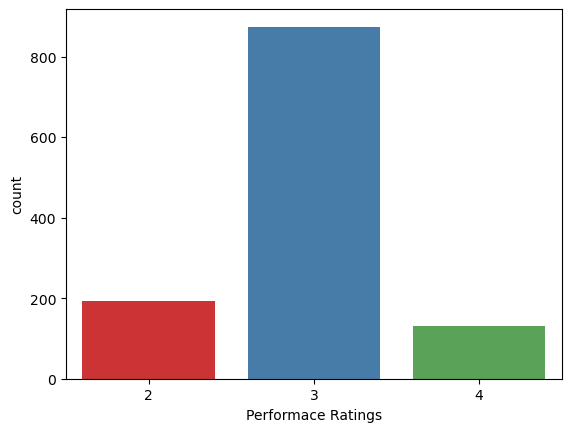

In [11]:
print(df['PerformanceRating'].value_counts())
sns.countplot(x='PerformanceRating',data=df,palette='Set1')
plt.xlabel("Performace Ratings")
plt.show()

#### Majority of the employees have performance rate 3 (874 employees). Only a few employees have rating of 4 (132) which is less than number of employees of rating 2 (194).

## (1) Univariate Analysis

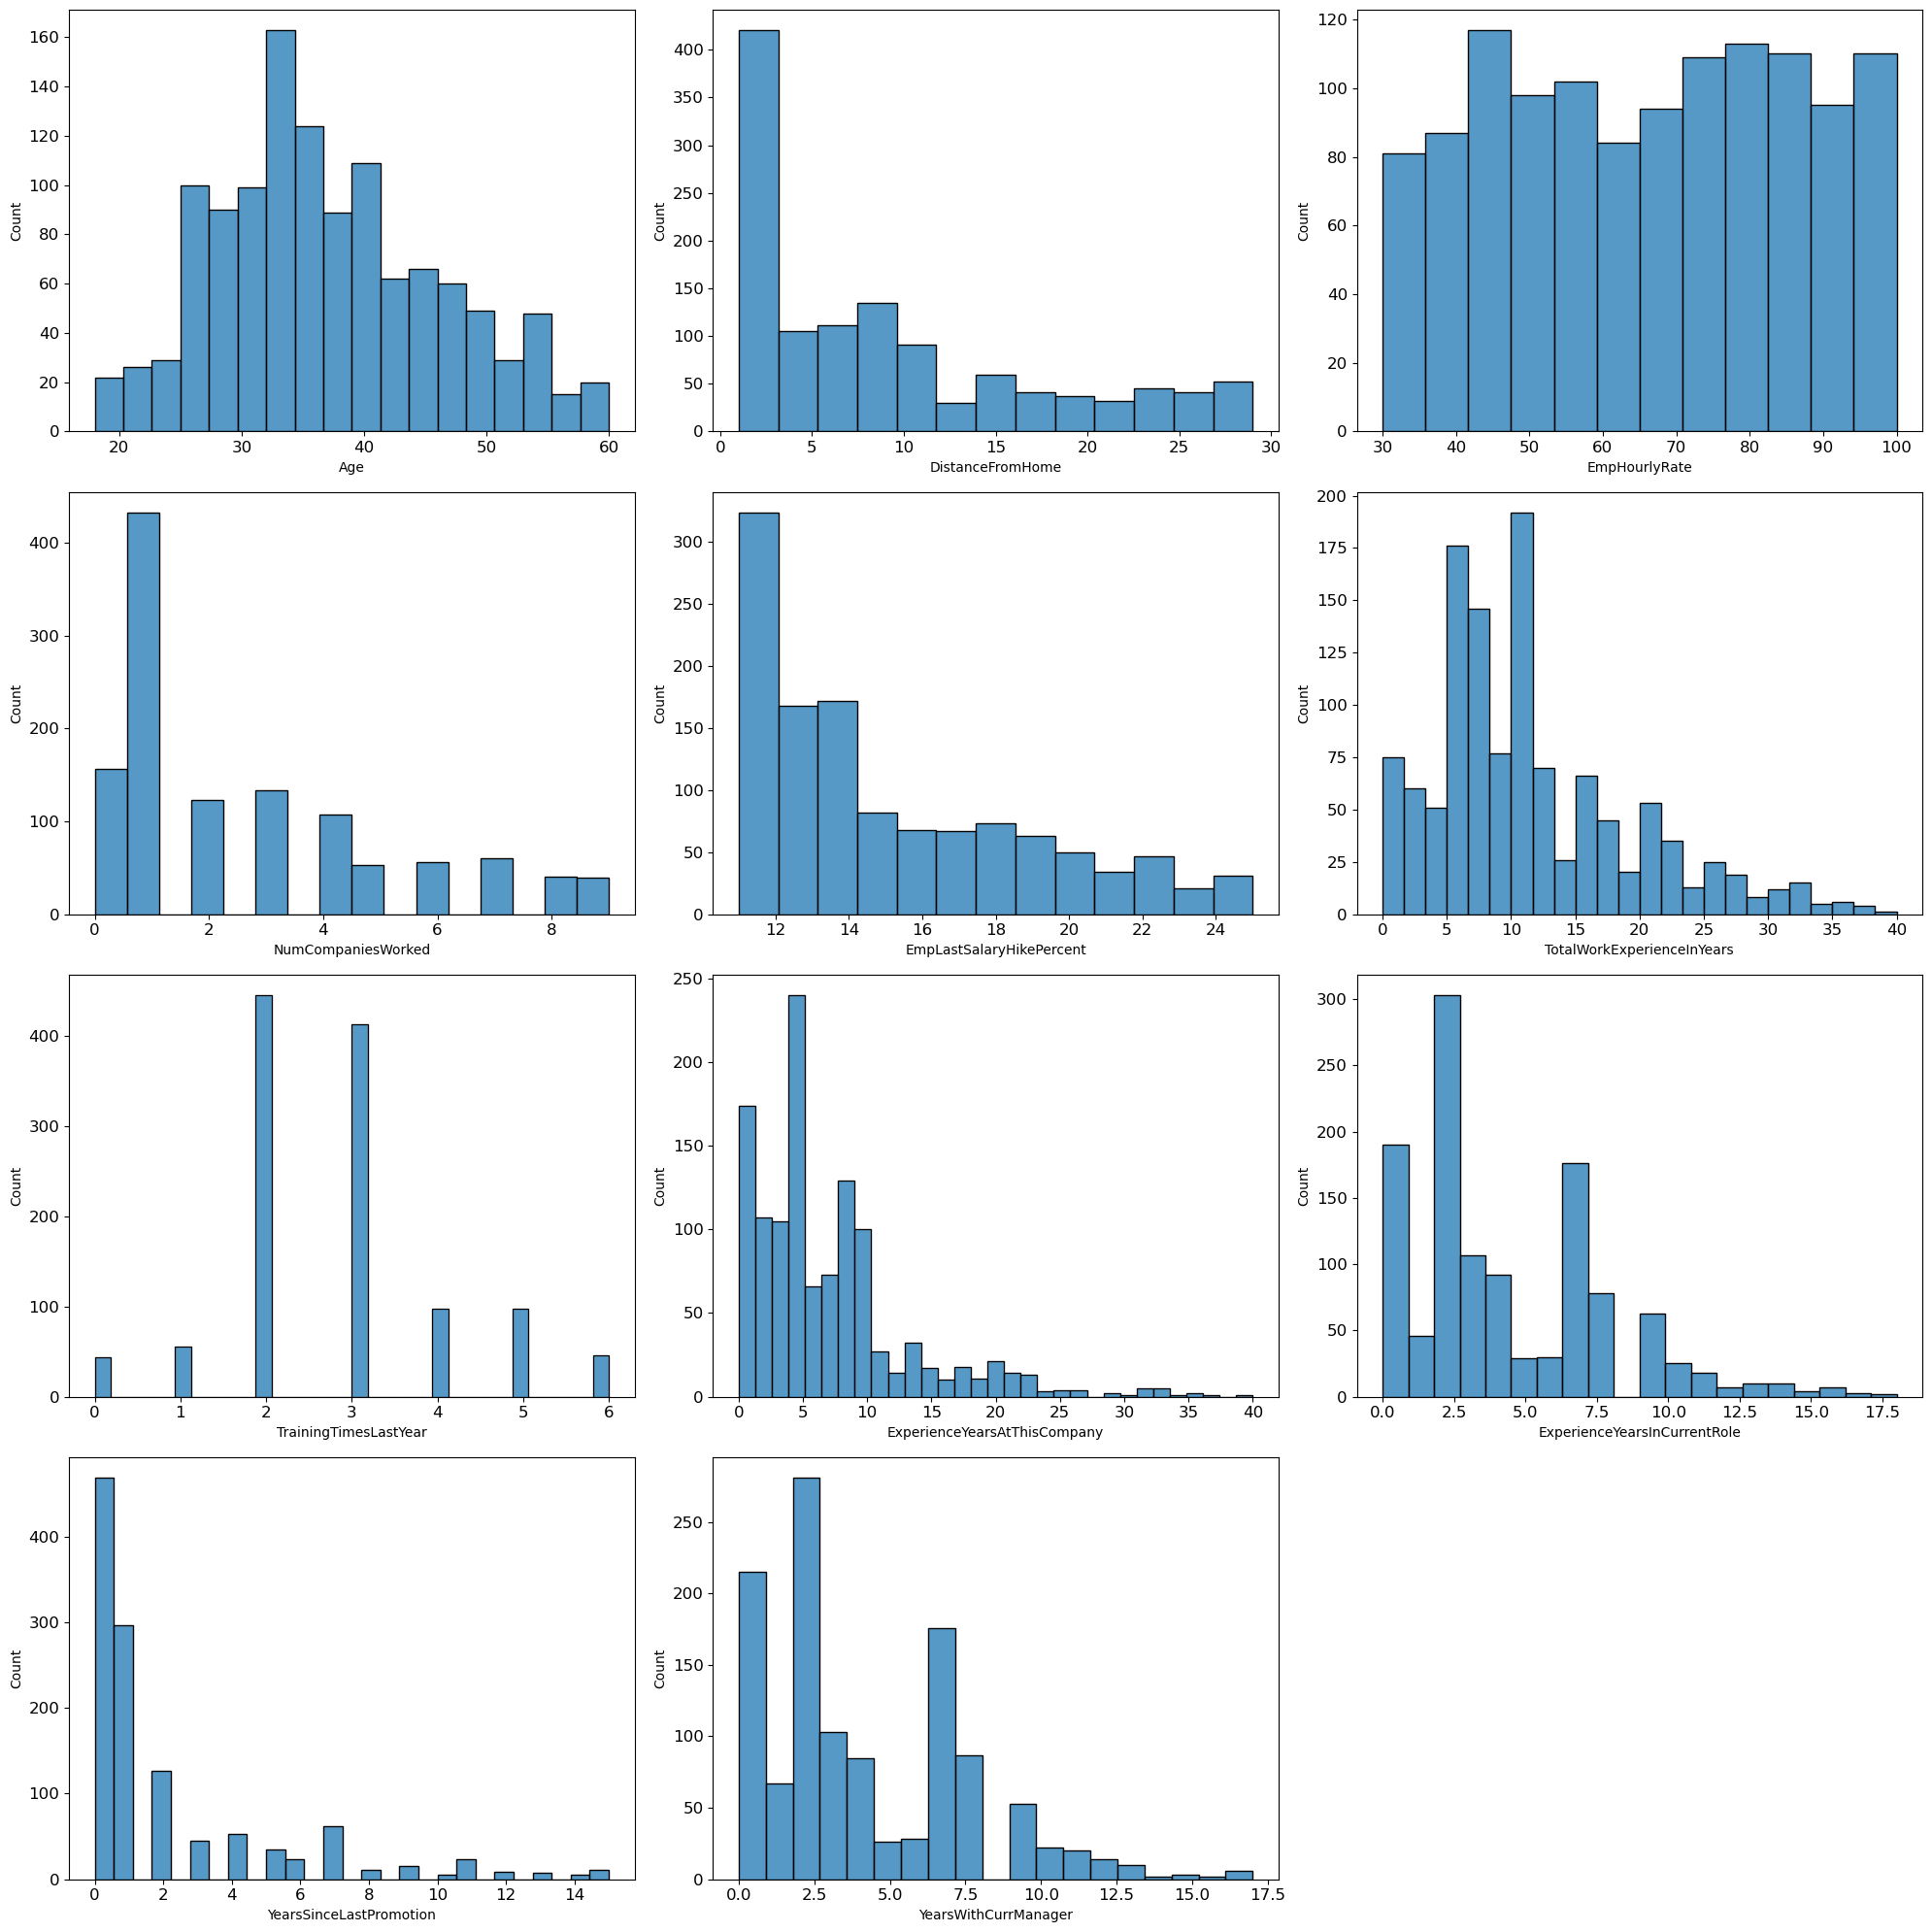

In [12]:
# Univariate Analysis for Numerical Data

plt.figure(figsize=(20,20))               
plotnumber = 1
for i in num_cols :             
    plt.subplot(4,3,plotnumber)           
    sns.histplot(x = df[i])             
    plt.xticks(fontsize=12)               
    plt.yticks(fontsize=12)              
    plotnumber = plotnumber + 1
plt.tight_layout()                        


#### Insights
* Age: Fairly normal working-age distribution.No extreme skew.
* DistanceFromHome: Right-skewed. Many employees live close, few live far .Possible outliers on higher side
* NumCompaniesWorked: Most employees worked in 2–3 companies
* EmpLastSalaryHikePercent: Slight right skew
* TotalWorkExperienceInYears: Right-skewed (few very experienced employees). Majority in early-mid career
* ExperienceYearsInCurrentRole: Most employees stay in role for 2–5 years
* YearsSinceLastPromotion: Many recently promoted employees
* YearsWithCurrManager: Most employees have stable manager relationship

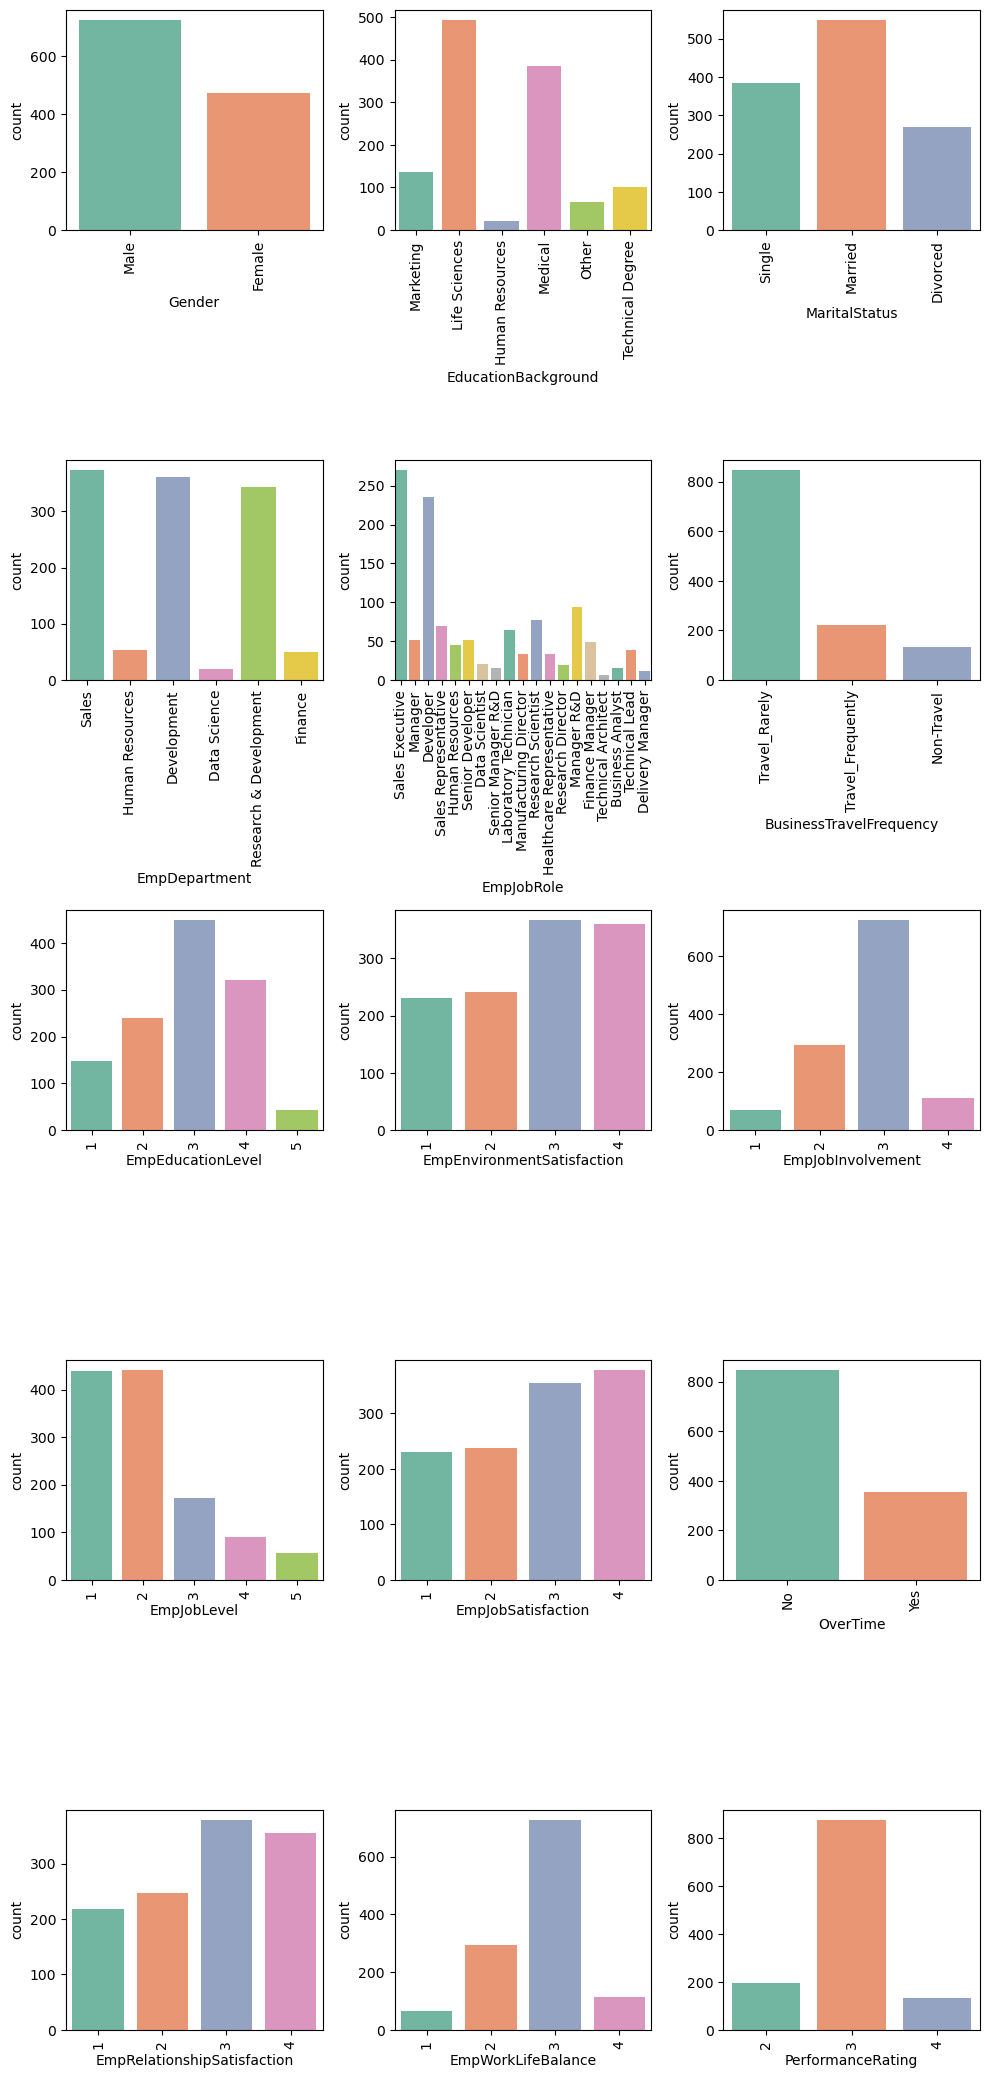

In [13]:
# Univariate Analysis for Categorical Data

plt.figure(figsize=(10,25))
plotnumber=1
for col in cat_cols:
    plt.subplot(6,3,plotnumber)
    sns.countplot(x=df[col],palette='Set2')
    plt.xticks(rotation=90)
    plotnumber=plotnumber+1
plt.tight_layout()

#### Insights
* EmpJobRole have so many categories(19).Proper encoding needed.
  

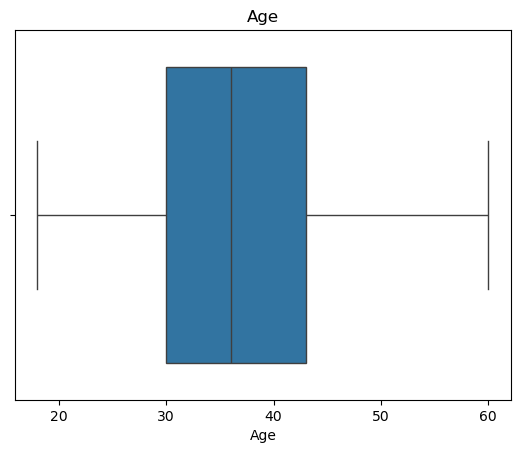

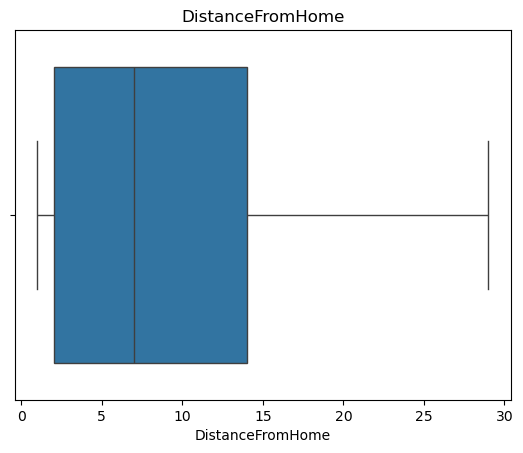

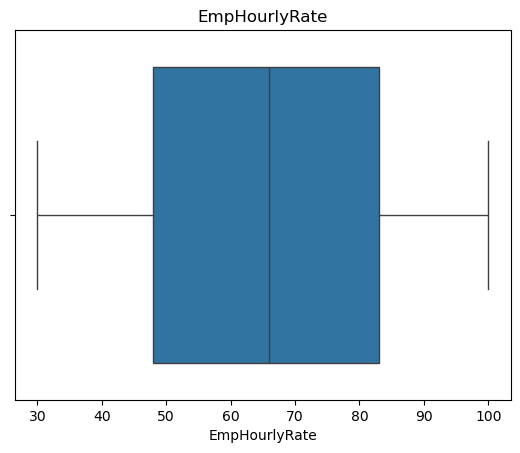

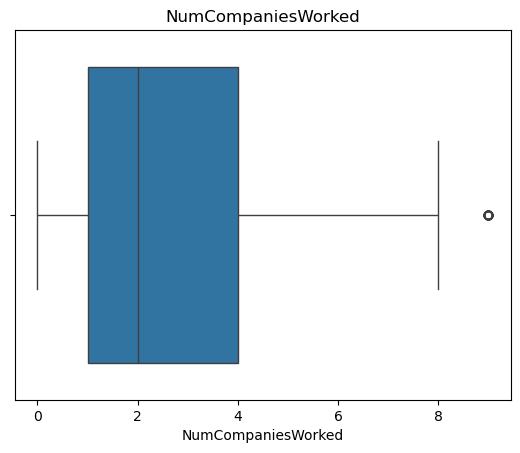

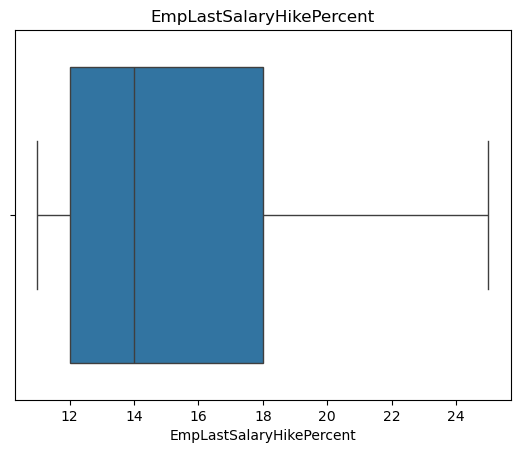

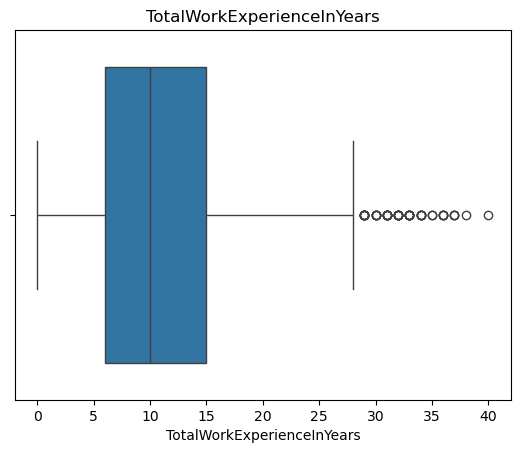

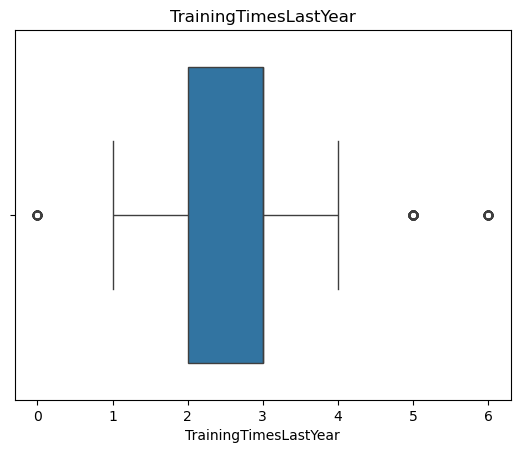

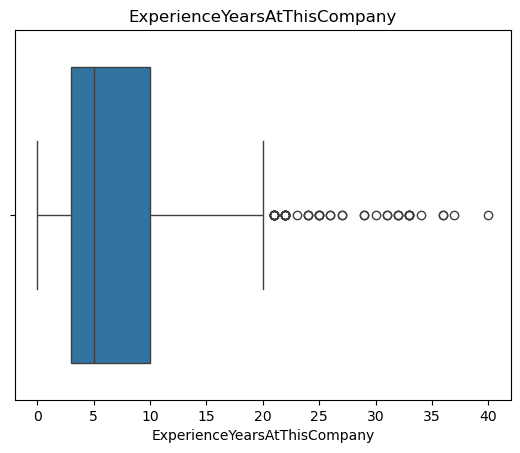

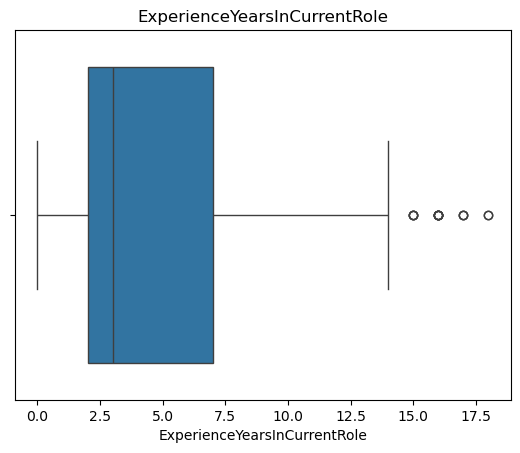

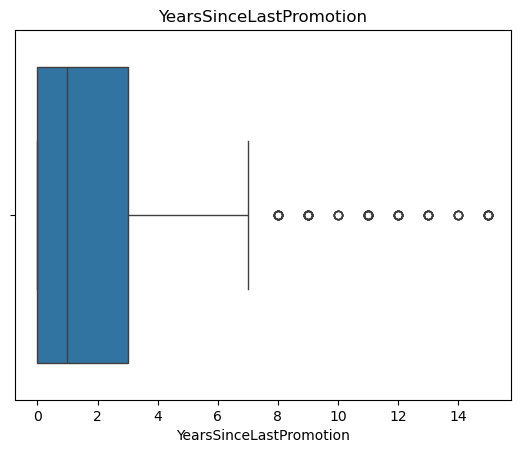

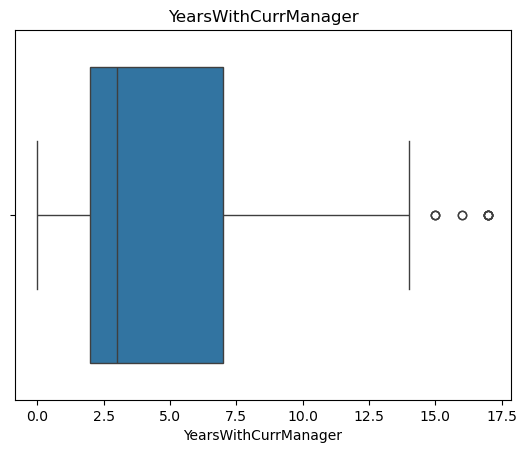

In [14]:
# Checking outliers

for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

#### Insights
Several features such as TotalWorkExperienceInYears, YearsSinceLastPromotion, and ExperienceYearsAtThisCompany showed the presence of extreme values.

However, upon analysis, these outliers were found to be valid and meaningful observations rather than data errors. Since these values represent natural variations in employee data, they were not removed.

# (2) Bivariate analysis

### Department wise performance

In [15]:
df.groupby('EmpDepartment')['PerformanceRating'].mean().sort_values(ascending=False)

EmpDepartment
Development               3.085873
Data Science              3.050000
Human Resources           2.925926
Research & Development    2.921283
Sales                     2.860590
Finance                   2.775510
Name: PerformanceRating, dtype: float64

In [16]:
pd.crosstab(df['EmpDepartment'], df['PerformanceRating'])

PerformanceRating,2,3,4
EmpDepartment,,,
Data Science,1,17,2
Development,13,304,44
Finance,15,30,4
Human Resources,10,38,6
Research & Development,68,234,41
Sales,87,251,35


### Insights
* Development department has the highest average performance    
 -> Strong overall performance   
 -> Consistent high ratings   
* Data Science has almost no low performers   
 -> Very consistent performance     
 -> High-quality workforce       
* Finance has the lowest average performance      
 -> Indicates weaker performance compared to other departments     
* Sales has the highest number of low performers      
 -> Indicates inconsistency       
 -> Wide variation in employee performance

## Department-wise Performance Analysis

The performance of employees was analyzed across different departments using both average performance ratings and distribution of ratings.

The Development department recorded the highest average performance rating (3.09), followed by Data Science (3.05), indicating strong overall performance in these areas. In contrast, the Finance department showed the lowest average rating (2.77), suggesting comparatively weaker performance.

Further analysis of rating distribution revealed that Development and Research & Development departments had the highest number of top performers (rating 4), while the Sales department had the highest number of low performers (rating 2), indicating performance inconsistency.

The Data Science department showed high consistency with very few low-performing employees, whereas departments like Sales and Research & Development exhibited greater variability in performance.

Overall, while some departments maintain consistent and high performance, others may require targeted improvements in employee training and management.

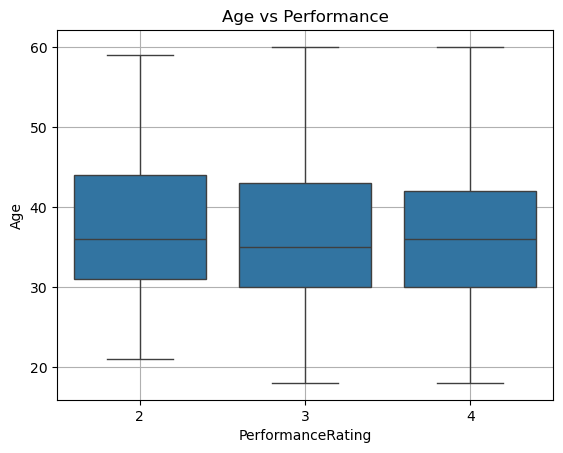

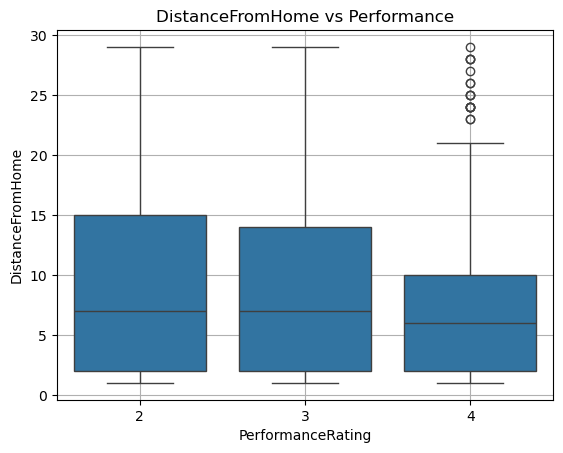

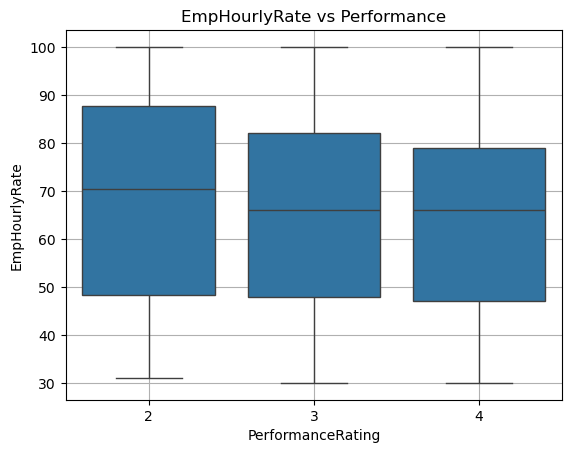

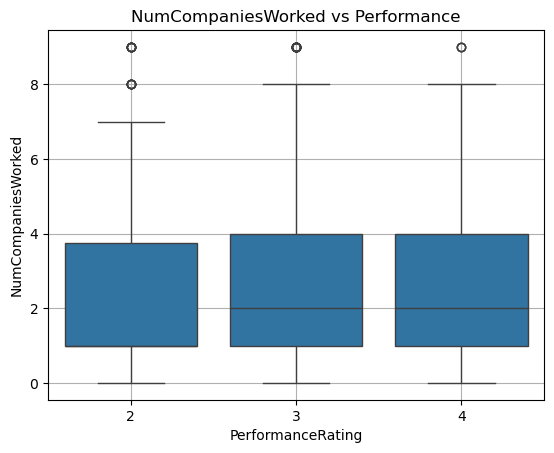

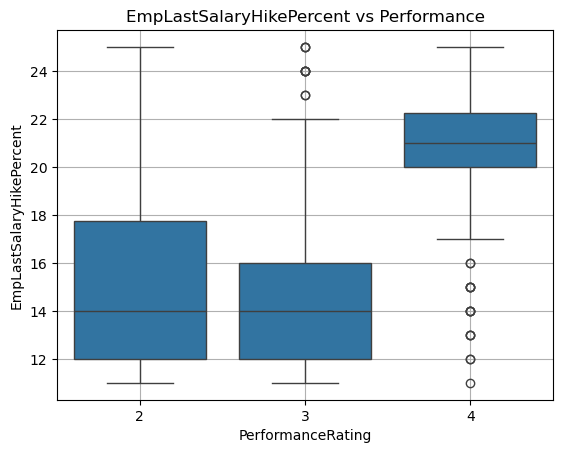

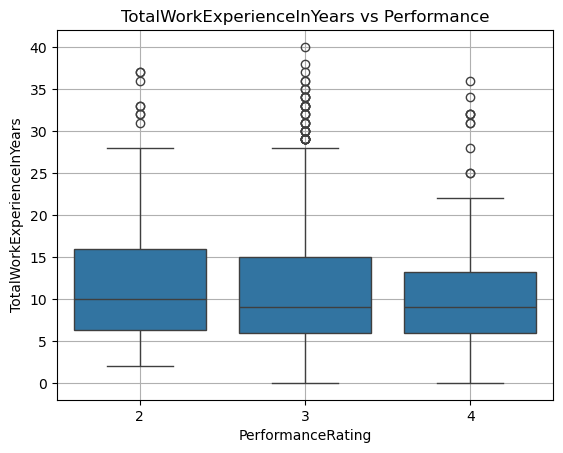

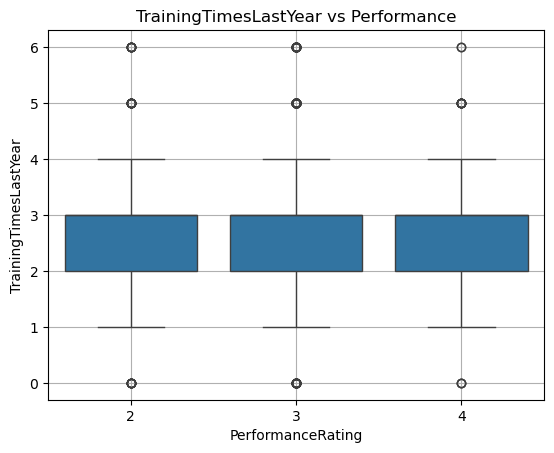

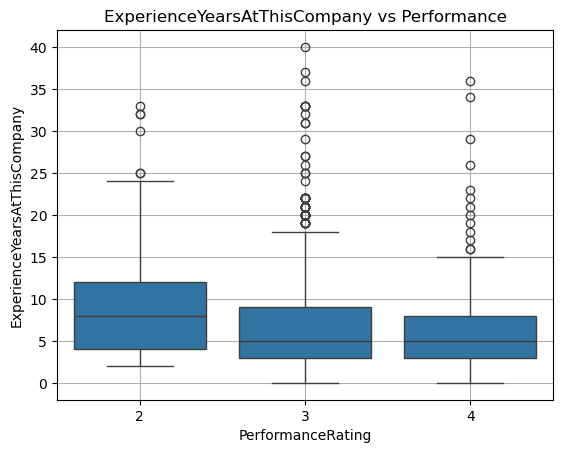

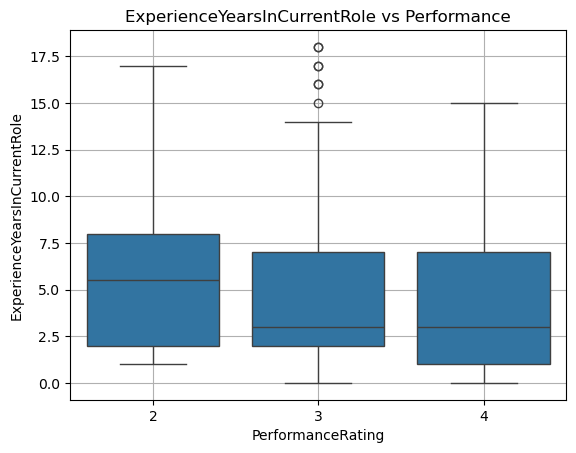

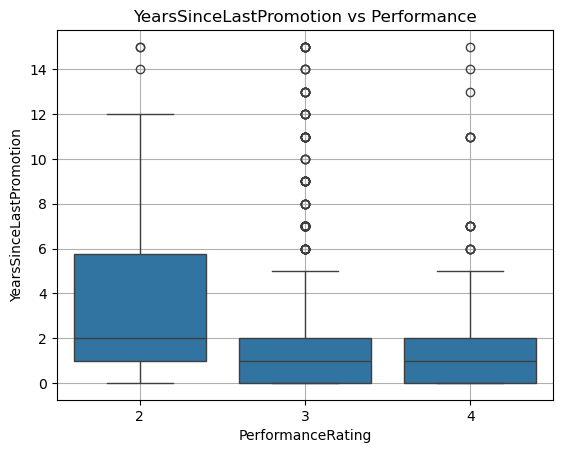

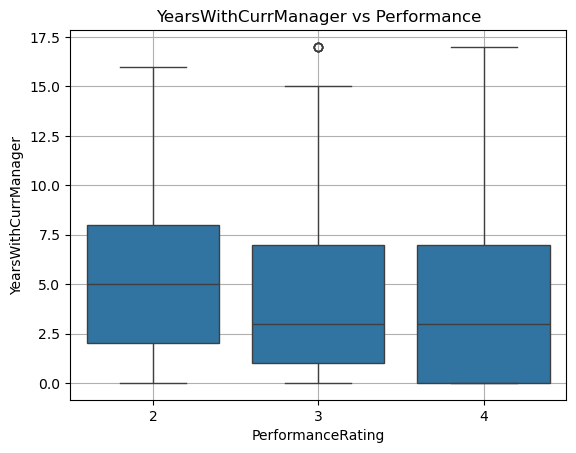

In [17]:
# Bivariate analysis of numerical features

for col in num_cols:
    sns.boxplot(x='PerformanceRating', y=col, data=df)
    plt.title(f"{col} vs Performance")
    plt.grid()
    plt.show()

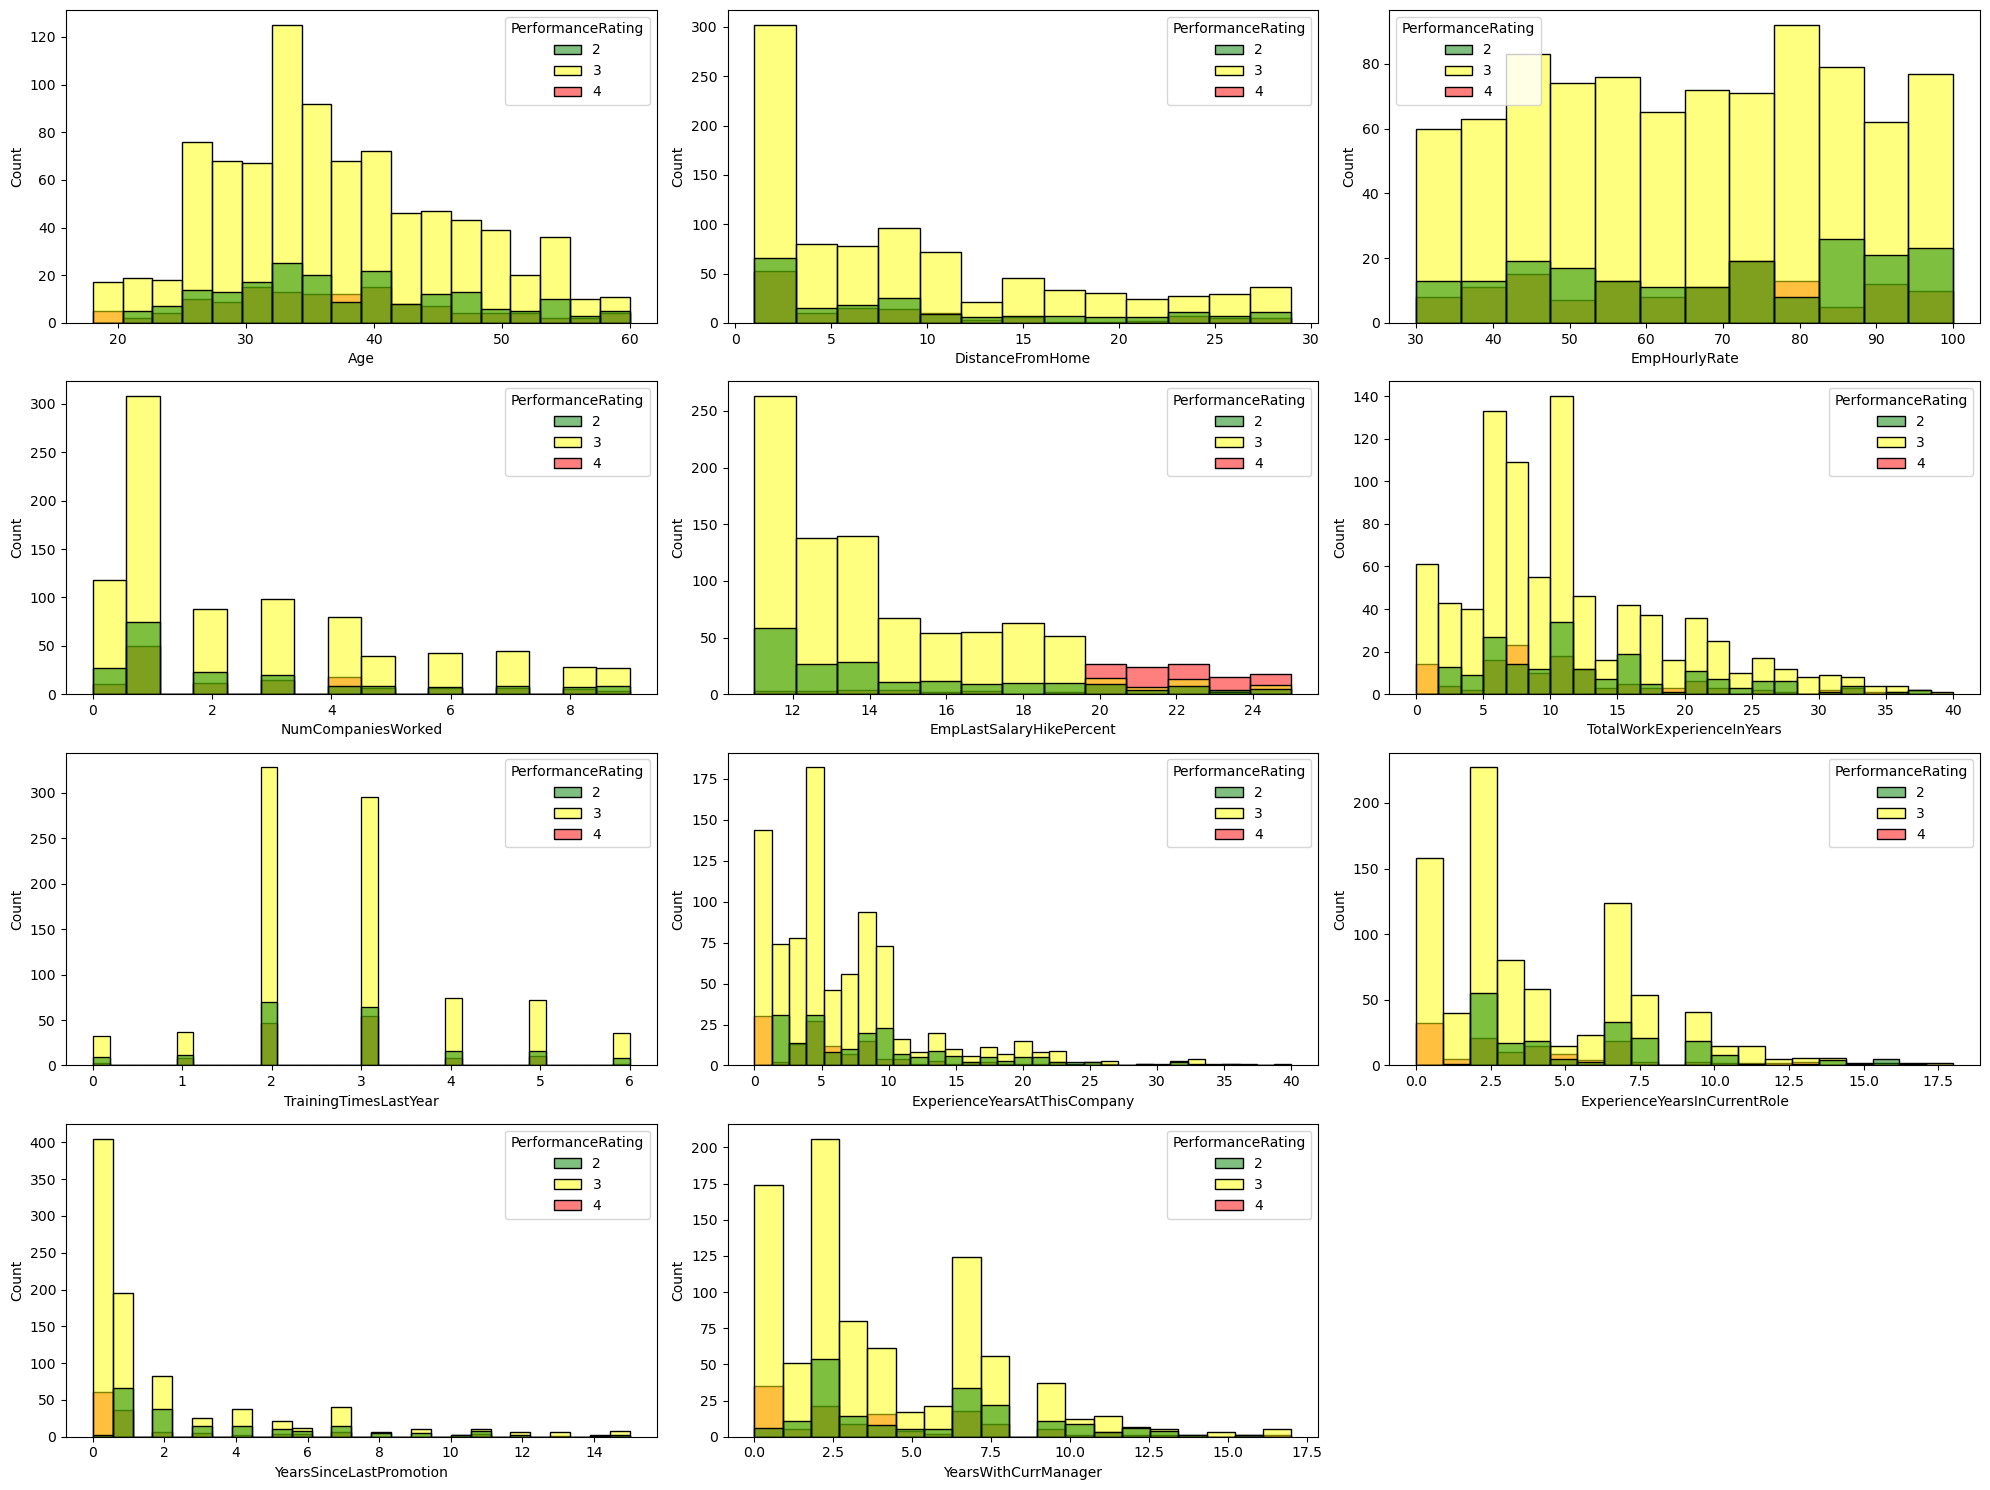

In [18]:
plt.figure(figsize=(20,15))
plotnumber=1
for col in num_cols:
    plt.subplot(4,3,plotnumber)
    sns.histplot(x=df[col],hue=df.PerformanceRating,palette=['green','yellow','red'])
    plt.xticks()
    plotnumber=plotnumber+1
plt.tight_layout()

In [19]:
df['AgeGroup'] = pd.cut(df['Age'],
                       bins=[18, 25, 35, 45, 60],
                       labels=['18-25', '26-35', '36-45', '46-60'])
print(df.groupby('AgeGroup')['PerformanceRating'].mean())
df['DistanceGroup'] = pd.cut(df['DistanceFromHome'],
                            bins=[0,5,10,20,30],
                            labels=['Very Near','Near','Moderate','Far'])
print(df.groupby('DistanceGroup')['PerformanceRating'].mean())
df['ExpGroup'] = pd.cut(df['TotalWorkExperienceInYears'],
                       bins=[0,5,10,20,40],
                       labels=['0-5','6-10','11-20','20+'])
print(df.groupby('ExpGroup')['PerformanceRating'].mean())
df['HikeGroup'] = pd.cut(df['EmpLastSalaryHikePercent'],
                        bins=[10,13,16,20,30],
                        labels=['Low','Medium','High','Very High'])
print(df.groupby('HikeGroup')['PerformanceRating'].mean())

AgeGroup
18-25    2.956989
26-35    2.945122
36-45    2.974093
46-60    2.900452
Name: PerformanceRating, dtype: float64
DistanceGroup
Very Near    2.965779
Near         2.955128
Moderate     2.927083
Far          2.905882
Name: PerformanceRating, dtype: float64
ExpGroup
0-5      2.991903
6-10     2.956879
11-20    2.933333
20+      2.877193
Name: PerformanceRating, dtype: float64
HikeGroup
Low          2.839431
Medium       2.872671
High         2.976285
Very High    3.481203
Name: PerformanceRating, dtype: float64


### Insights
* Employees aged 36–45 perform the best.Employees aged 46–60 perform the lowest
* Closer employees perform better. Performance decreases as distance increases
* Less experienced employees (0–5 years) perform the best.Highly experienced employees (20+) perform the lowest
* Salary hike is strongly correlated with performance. Employees with very high hikes perform much better

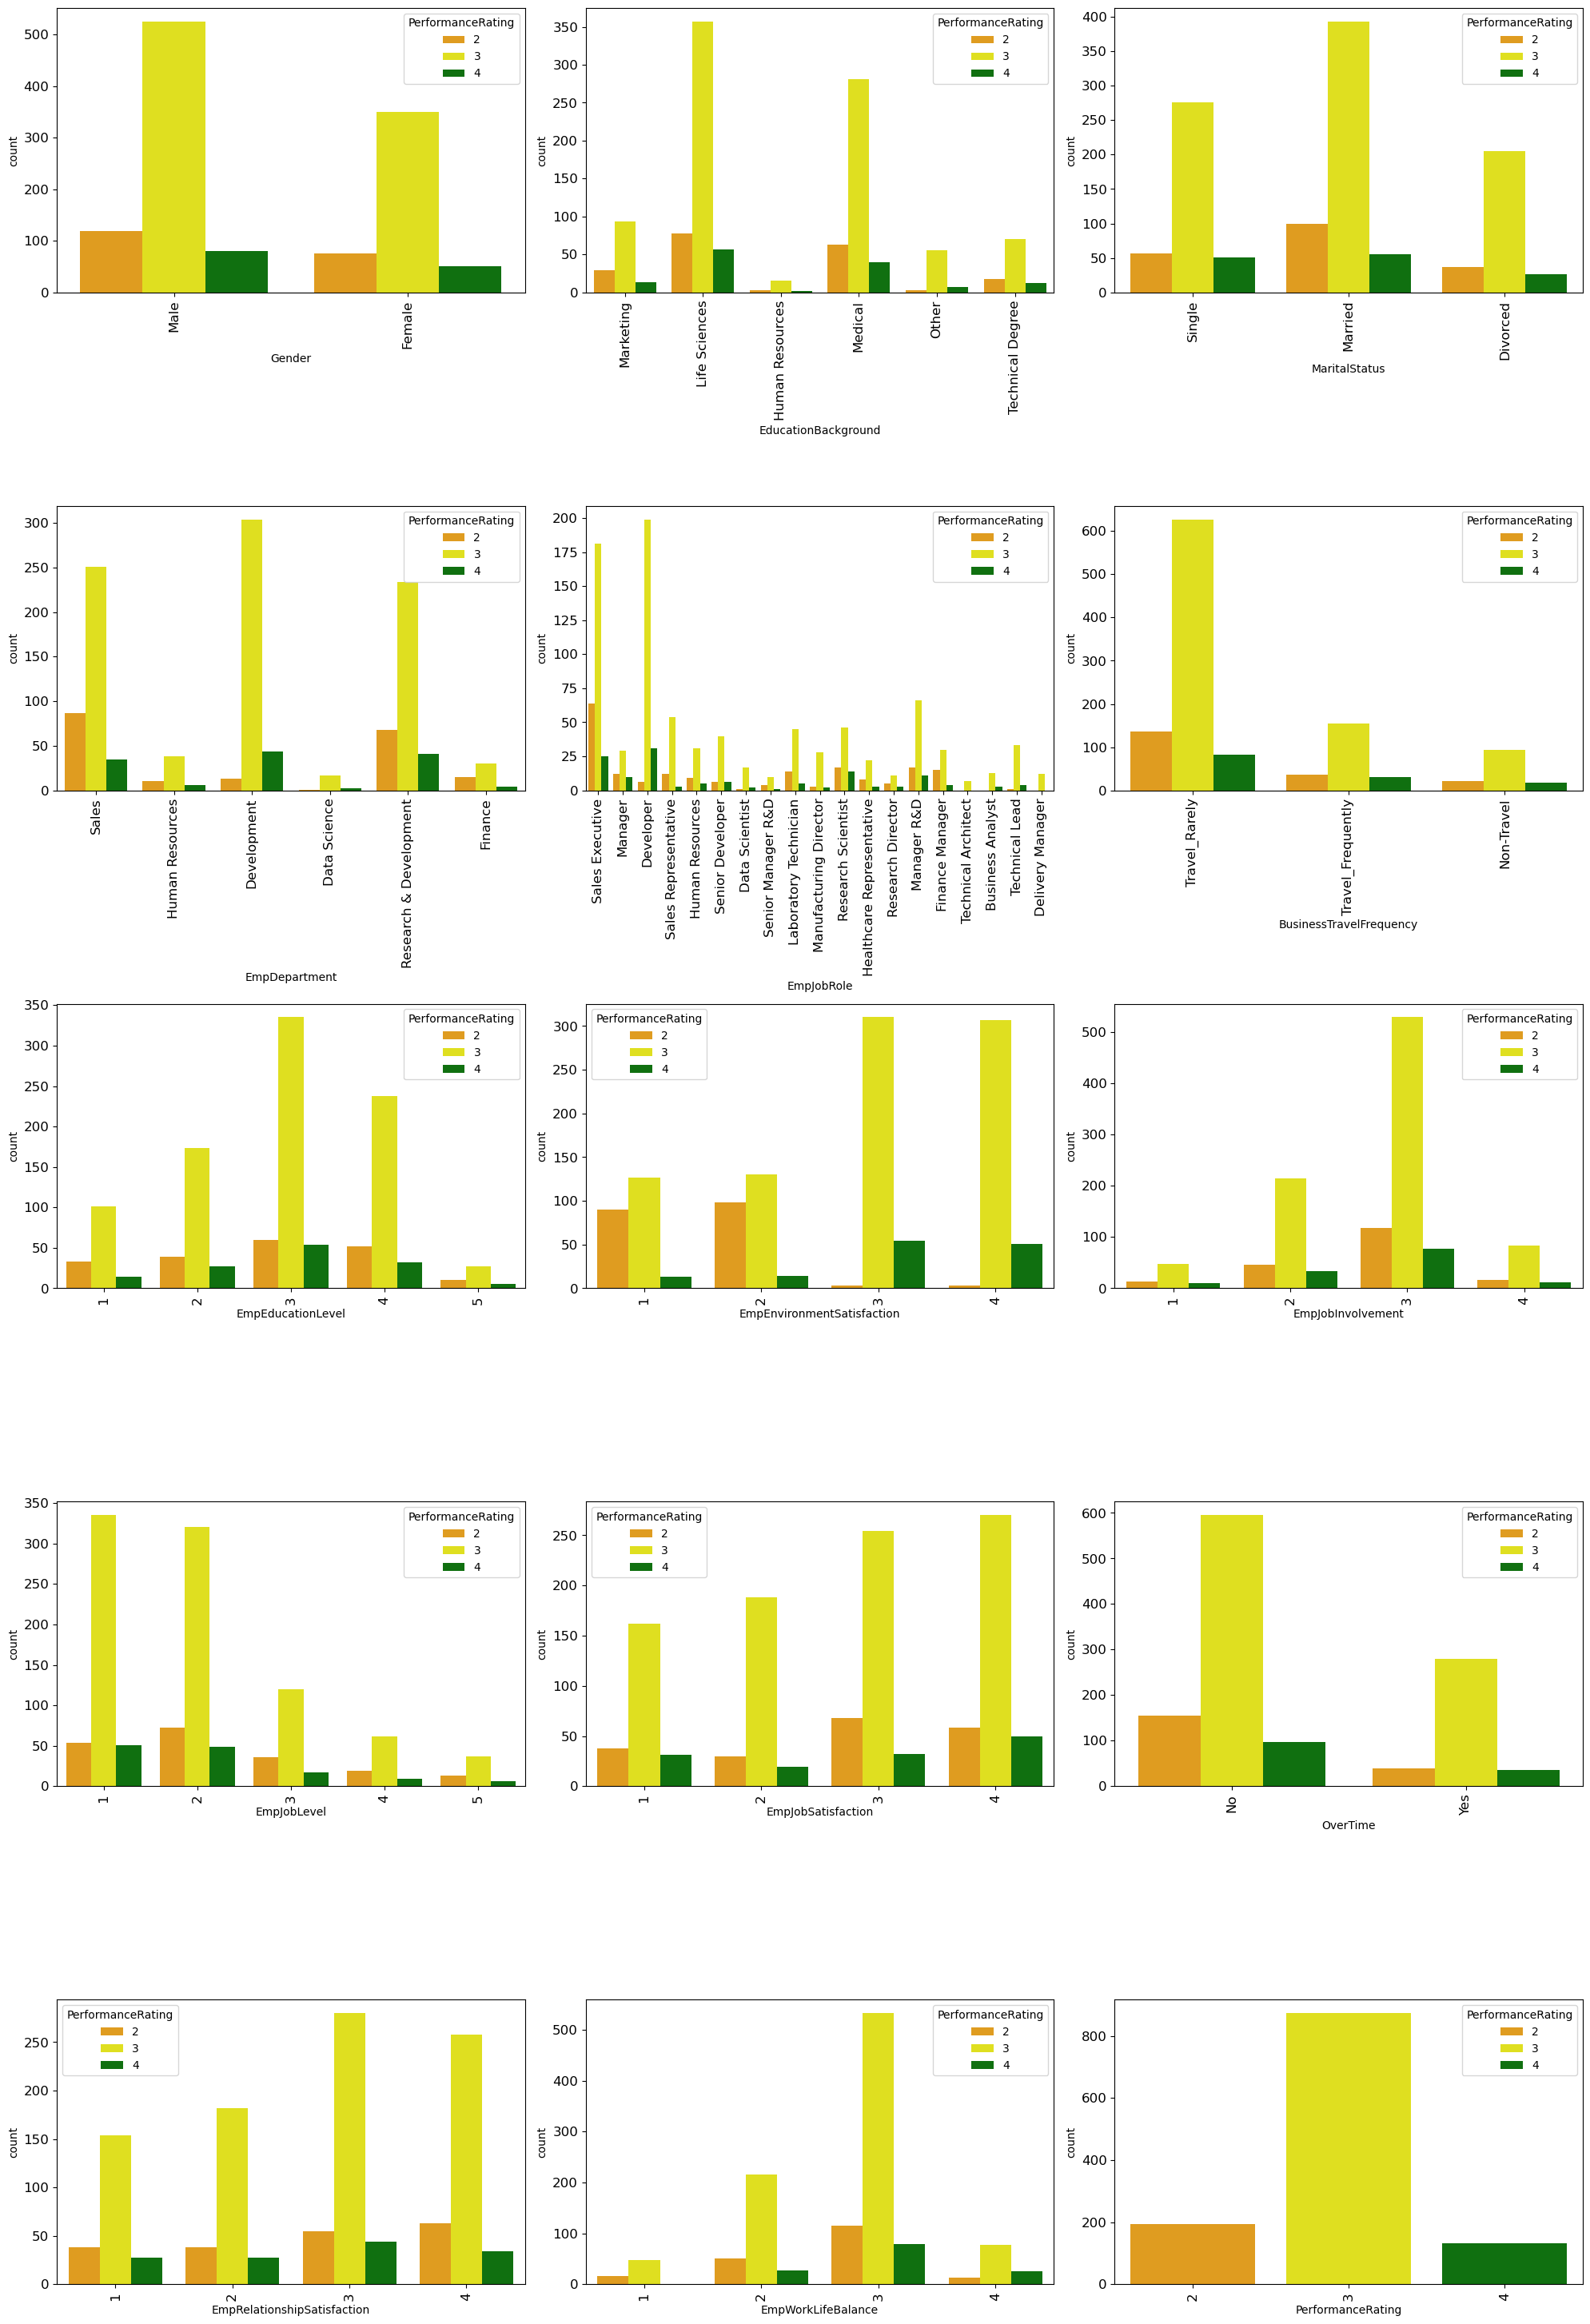

In [20]:
# Bivariate analysis of categorical features

plt.figure(figsize=(20,35))                       
plotnumber = 1
for col in cat_cols :                       
    plt.subplot(6,3,plotnumber)                   
    sns.countplot(x = df[col],hue = df.PerformanceRating,palette=["orange","yellow","green"])
    plt.xticks(rotation = 90,fontsize=12)         
    plt.yticks(fontsize=12)                       
    plotnumber = plotnumber + 1
plt.tight_layout()

In [21]:
features = ['EducationBackground', 'EmpJobRole', 'OverTime']

for col in features:
    print(f"\n--- {col} ---")
    print(df.groupby(col)['PerformanceRating'].mean().sort_values(ascending=False))


--- EducationBackground ---
EducationBackground
Other               3.060606
Life Sciences       2.957317
Human Resources     2.952381
Medical             2.940104
Technical Degree    2.940000
Marketing           2.890511
Name: PerformanceRating, dtype: float64

--- EmpJobRole ---
EmpJobRole
Business Analyst             3.187500
Developer                    3.105932
Technical Lead               3.078947
Data Scientist               3.050000
Delivery Manager             3.000000
Senior Developer             3.000000
Technical Architect          3.000000
Manufacturing Director       2.969697
Research Scientist           2.961039
Manager                      2.960784
Manager R&D                  2.936170
Human Resources              2.911111
Research Director            2.894737
Sales Representative         2.869565
Laboratory Technician        2.859375
Sales Executive              2.855556
Healthcare Representative    2.848485
Senior Manager R&D           2.800000
Finance Manager       

### Insights
* Education background showed minimal variation in performance across categories,indicating that it has a limited impact on employee performance
* Marketing has the lowest performance
* Job role significantly influences performance, especially technical vs non-technical roles
* Technical roles perform better.Finance & Sales roles perform lower
* Employees who work overtime perform slightly better

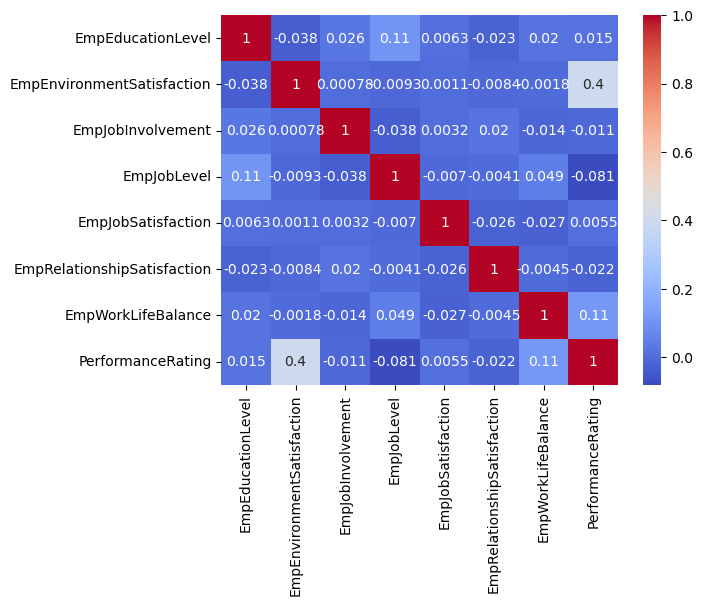

In [22]:
ord_cols=['EmpEducationLevel','EmpEnvironmentSatisfaction','EmpJobInvolvement','EmpJobLevel',
          'EmpJobSatisfaction','EmpRelationshipSatisfaction','EmpWorkLifeBalance']
corr = df[ord_cols + ['PerformanceRating']].corr(method='spearman')

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

### Insights
Spearman correlation analysis was performed on ordinal features to evaluate their relationship with employee performance. Among all features, EmpEnvironmentSatisfaction showed a strong positive correlation (0.39) with performance rating, indicating that employees with higher satisfaction levels tend to perform better.

EmpWorkLifeBalance showed a weak positive relationship, while EmpJobLevel exhibited a slight negative correlation with performance, suggesting that higher-level employees may not necessarily achieve higher performance ratings.

Other features such as EmpJobSatisfaction, EmpJobInvolvement, and EmpRelationshipSatisfaction showed negligible correlation with performance, indicating limited direct influence.

# Preprocessing

In [23]:
df = pd.read_excel("Employee_Performance_Data.xls")
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,55,3,2,4,1,No,12,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,42,3,2,1,2,No,12,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,48,2,3,1,5,Yes,21,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,73,2,5,4,3,No,15,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,84,3,2,1,8,No,14,4,10,1,3,2,2,2,2,No,3


In [24]:
df=df.drop(['EmpNumber','Attrition'],axis=1)  
num_cols=['Age', 'DistanceFromHome','EmpHourlyRate','NumCompaniesWorked',
          'EmpLastSalaryHikePercent', 'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
        'ExperienceYearsAtThisCompany','ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager']
cat_cols=df.drop(num_cols,axis=1).columns.tolist()

In [25]:
df.isnull().sum()

Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
PerformanceRating               0
dtype: int64

In [26]:
cat_cols

['Gender',
 'EducationBackground',
 'MaritalStatus',
 'EmpDepartment',
 'EmpJobRole',
 'BusinessTravelFrequency',
 'EmpEducationLevel',
 'EmpEnvironmentSatisfaction',
 'EmpJobInvolvement',
 'EmpJobLevel',
 'EmpJobSatisfaction',
 'OverTime',
 'EmpRelationshipSatisfaction',
 'EmpWorkLifeBalance',
 'PerformanceRating']

In [27]:
ord_cols=['EmpEducationLevel', 'EmpEnvironmentSatisfaction', 'EmpJobInvolvement','EmpJobLevel',
 'EmpJobSatisfaction','EmpRelationshipSatisfaction','EmpWorkLifeBalance']
nominal=['EducationBackground', 'MaritalStatus', 'EmpDepartment','EmpJobRole', 'BusinessTravelFrequency']

In [28]:
df['Gender']=df['Gender'].map({'Male':1,'Female':0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

In [29]:
freq = df['EmpJobRole'].value_counts(normalize=True)
rare_roles = freq[freq <0.02].index   # less than 2%

df['EmpJobRole'] = df['EmpJobRole'].replace(rare_roles, 'Other')

The EmpJobRole feature had high cardinality with many low-frequency categories. To reduce dimensionality and avoid overfitting, roles with less than 2% frequency were grouped into an “Other” category.

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

num_cols=num_cols+ord_cols+['Gender', 'OverTime'] 

preprocessor = ColumnTransformer(
    transformers=[
        ("nominal", OneHotEncoder(drop='first', handle_unknown='ignore'),nominal),
        ("num", "passthrough", num_cols)
    ]
)

### Feature selection

In [31]:
corr = df.corr(numeric_only=True)
corr['PerformanceRating'].sort_values(ascending=False)

PerformanceRating               1.000000
EmpEnvironmentSatisfaction      0.395561
EmpLastSalaryHikePercent        0.333722
EmpWorkLifeBalance              0.124429
OverTime                        0.050206
NumCompaniesWorked              0.020980
EmpEducationLevel               0.020529
EmpJobSatisfaction              0.000606
Gender                         -0.001780
TrainingTimesLastYear          -0.005443
EmpJobInvolvement              -0.010539
EmpRelationshipSatisfaction    -0.019502
Age                            -0.040164
EmpHourlyRate                  -0.043116
DistanceFromHome               -0.046142
TotalWorkExperienceInYears     -0.068141
EmpJobLevel                    -0.076632
ExperienceYearsAtThisCompany   -0.111645
YearsWithCurrManager           -0.122313
ExperienceYearsInCurrentRole   -0.147638
YearsSinceLastPromotion        -0.167629
Name: PerformanceRating, dtype: float64

In [32]:
X = df.drop(columns=['PerformanceRating'])
y = df['PerformanceRating']

In [33]:
X_processed = preprocessor.fit_transform(X)

In [34]:
feature_names = preprocessor.get_feature_names_out()

In [35]:
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

In [36]:
from sklearn.feature_selection import f_classif

f_values, p_values = f_classif(X_processed_df, y)

feature_scores = pd.DataFrame({
    'Feature': X_processed_df.columns,
    'Score': f_values,
    'p_value': p_values
}).sort_values(by='Score', ascending=False)

print(feature_scores)

                                              Feature       Score  \
31                      num__EmpLastSalaryHikePercent  240.837433   
39                    num__EmpEnvironmentSatisfaction  159.861194   
7                  nominal__EmpDepartment_Development   31.647536   
36                       num__YearsSinceLastPromotion   26.217197   
35                  num__ExperienceYearsInCurrentRole   20.505445   
37                          num__YearsWithCurrManager   14.641569   
34                  num__ExperienceYearsAtThisCompany   12.384997   
44                            num__EmpWorkLifeBalance   11.056744   
11                       nominal__EmpDepartment_Sales   10.515436   
21                nominal__EmpJobRole_Sales Executive    7.478021   
46                                      num__OverTime    5.680531   
41                                   num__EmpJobLevel    5.319472   
12                nominal__EmpJobRole_Finance Manager    3.972813   
8                      nominal__Em

In [37]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_processed, y)

importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

                                              Feature  Importance
31                      num__EmpLastSalaryHikePercent    0.184110
39                    num__EmpEnvironmentSatisfaction    0.160238
36                       num__YearsSinceLastPromotion    0.085749
29                                 num__EmpHourlyRate    0.042597
27                                           num__Age    0.039569
34                  num__ExperienceYearsAtThisCompany    0.037675
35                  num__ExperienceYearsInCurrentRole    0.035596
28                              num__DistanceFromHome    0.033373
32                    num__TotalWorkExperienceInYears    0.029867
7                  nominal__EmpDepartment_Development    0.029490
37                          num__YearsWithCurrManager    0.028875
44                            num__EmpWorkLifeBalance    0.024868
30                            num__NumCompaniesWorked    0.023200
33                         num__TrainingTimesLastYear    0.021801
38        

Gender,EmpJobSatisfaction,EmpJobInvolvement and TrainingTimeLastYear do not give much information about the performance. so drop these columns to reduce dimention

In [38]:
X=X_processed_df.drop(['num__Gender' , 'num__EmpJobSatisfaction' ,'num__EmpJobInvolvement', 'num__TrainingTimesLastYear'],axis=1)

In [39]:
X.head()

,nominal__EducationBackground_Life Sciences,nominal__EducationBackground_Marketing,nominal__EducationBackground_Medical,nominal__EducationBackground_Other,nominal__EducationBackground_Technical Degree,nominal__MaritalStatus_Married,nominal__MaritalStatus_Single,nominal__EmpDepartment_Development,nominal__EmpDepartment_Finance,nominal__EmpDepartment_Human Resources,nominal__EmpDepartment_Research & Development,nominal__EmpDepartment_Sales,nominal__EmpJobRole_Finance Manager,nominal__EmpJobRole_Healthcare Representative,nominal__EmpJobRole_Human Resources,nominal__EmpJobRole_Laboratory Technician,nominal__EmpJobRole_Manager,nominal__EmpJobRole_Manager R&D,nominal__EmpJobRole_Manufacturing Director,nominal__EmpJobRole_Other,nominal__EmpJobRole_Research Scientist,nominal__EmpJobRole_Sales Executive,nominal__EmpJobRole_Sales Representative,nominal__EmpJobRole_Senior Developer,nominal__EmpJobRole_Technical Lead,nominal__BusinessTravelFrequency_Travel_Frequently,nominal__BusinessTravelFrequency_Travel_Rarely,num__Age,num__DistanceFromHome,num__EmpHourlyRate,num__NumCompaniesWorked,num__EmpLastSalaryHikePercent,num__TotalWorkExperienceInYears,num__ExperienceYearsAtThisCompany,num__ExperienceYearsInCurrentRole,num__YearsSinceLastPromotion,num__YearsWithCurrManager,num__EmpEducationLevel,num__EmpEnvironmentSatisfaction,num__EmpJobLevel,num__EmpRelationshipSatisfaction,num__EmpWorkLifeBalance,num__OverTime
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,32.0,10.0,55.0,1.0,12.0,10.0,10.0,7.0,0.0,8.0,3.0,4.0,2.0,4.0,2.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,47.0,14.0,42.0,2.0,12.0,20.0,7.0,7.0,1.0,7.0,4.0,4.0,2.0,4.0,3.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,40.0,5.0,48.0,5.0,21.0,20.0,18.0,13.0,1.0,12.0,4.0,4.0,3.0,3.0,3.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,41.0,10.0,73.0,3.0,15.0,23.0,21.0,6.0,12.0,6.0,4.0,2.0,5.0,2.0,2.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,60.0,16.0,84.0,8.0,14.0,10.0,2.0,2.0,2.0,2.0,4.0,1.0,2.0,4.0,3.0,0.0


In [40]:
X.shape

(1200, 43)

In [41]:
y.value_counts()

PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64

# Model Training

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

sample_weights = np.array([class_weights[y] for y in y_train])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "SVM": SVC(class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier()
}

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


results=[]

for name, model in models.items():
    
    if name in ["Logistic Regression", "SVM"]:
        # Need scaling for these models
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        
    elif name == "Gradient Boosting":
        model.fit(X_train, y_train, sample_weight=sample_weights) 
        preds = model.predict(X_test)   
        
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    
    # Calculate metrics
    acc = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average='macro')
    f1_weighted = f1_score(y_test, preds, average='weighted')
    precision_macro = precision_score(y_test, preds, average='macro')
    recall_macro = recall_score(y_test, preds, average='macro')
    
    # Store results
    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "F1_macro": round(f1_macro, 4),
        "F1_weighted": round(f1_weighted, 4),
        "Precision_macro": round(precision_macro, 4),
        "Recall_macro": round(recall_macro, 4)
    })
    print(f"\n{name}")
    print(classification_report(y_test, preds))

# Convert to DataFrame
results_df = pd.DataFrame(results)
print("------------------------------------------------------------")
print(results_df.sort_values(by="F1_macro", ascending=False))


Logistic Regression
              precision    recall  f1-score   support

           2       0.49      0.74      0.59        39
           3       0.93      0.76      0.84       175
           4       0.50      0.73      0.59        26

    accuracy                           0.75       240
   macro avg       0.64      0.74      0.67       240
weighted avg       0.81      0.75      0.77       240


SVM
              precision    recall  f1-score   support

           2       0.55      0.82      0.66        39
           3       0.91      0.81      0.85       175
           4       0.48      0.50      0.49        26

    accuracy                           0.78       240
   macro avg       0.65      0.71      0.67       240
weighted avg       0.81      0.78      0.78       240


Random Forest
              precision    recall  f1-score   support

           2       0.91      0.74      0.82        39
           3       0.91      0.98      0.95       175
           4       1.00      0.73 

In [45]:
y_xgb = df['PerformanceRating'] - 2   # converts [2,3,4] → [0,1,2] since XGB expect labels to be o based
X_train, X_test, y_train, y_test = train_test_split(
    X, y_xgb, test_size=0.2, random_state=42, stratify=y
)
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train, y_train,sample_weight=sample_weights)
y_pred = xgb_model.predict(X_test)


print("XGBoost Model")
print(f"accuracy:{accuracy_score(y_test, y_pred)}")
print(f"f1_macro:{ f1_score(y_test, y_pred, average='macro')}")
print(f"f1_weighted:{f1_score(y_test, y_pred, average='weighted')}")
print(f"precision_macro:{precision_score(y_test, y_pred, average='macro')}")
print(f"recall_macro :{recall_score(y_test, y_pred, average='macro')}")

XGBoost Model
accuracy:0.925
f1_macro:0.8818153364632239
f1_weighted:0.9239154929577464
precision_macro:0.9009259259259258
recall_macro :0.8646398046398046


# Model comparison

Multiple classification models were evaluated to predict employee performance, including Logistic Regression, Support Vector Machine (SVM), Random Forest, Gradient Boosting, and XGBoost. The models were compared using accuracy, macro F1-score, weighted F1-score, precision, and recall.

Linear models such as Logistic Regression and SVM showed relatively lower performance, with accuracy around 75–78% and macro F1-scores around 0.67. These models struggled to effectively capture complex patterns in the data, particularly for minority classes.

Tree-based models performed significantly better. Random Forest achieved an accuracy of 91% with improved class-wise performance, especially for the majority class. However, it showed slightly lower recall for minority classes.

Gradient Boosting and XGBoost delivered the best overall performance. Gradient Boosting achieved an accuracy of 92.9% with a macro F1-score of 0.89, while XGBoost slightly outperformed it with an accuracy of 93.3% and macro F1-score of 0.89. Both models demonstrated strong balance across all classes, making them more reliable for imbalanced data.

Overall, XGBoost was selected as the best-performing model due to its highest accuracy and balanced performance across classes, closely followed by Gradient Boosting.

# Hyperparameter tuning

### Gradient boost Classifier

In [46]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10]
}

gb_search = RandomizedSearchCV(
    gb,
    param_grid_gb,
    n_iter=10,
    scoring='f1_macro',
    cv=5,
    random_state=42,
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

print("Best GB:", gb_search.best_params_)

Best GB: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 3, 'learning_rate': 0.01}


In [47]:
y_pred =gb_search.predict(X_test)

print("---Gradient boost model---\n")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1_macro:", f1_score(y_test, y_pred, average='macro'))
print("F1_weighted:", f1_score(y_test, y_pred, average='weighted'))
print("Precision_macro:", precision_score(y_test, y_pred, average='macro'))
print("Recall_macro:", recall_score(y_test, y_pred, average='macro'))

---Gradient boost model---

              precision    recall  f1-score   support

           0       0.89      0.85      0.87        39
           1       0.93      0.98      0.96       175
           2       1.00      0.73      0.84        26

    accuracy                           0.93       240
   macro avg       0.94      0.85      0.89       240
weighted avg       0.93      0.93      0.93       240

Accuracy: 0.9333333333333333
F1_macro: 0.8903609224236698
F1_weighted: 0.9312999953846237
Precision_macro: 0.9422248335291813
Recall_macro: 0.8532600732600732


### XGBoost Classifier

In [48]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='mlogloss')

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1]
}

xgb_search = RandomizedSearchCV(
    xgb,
    param_grid_xgb,
    n_iter=10,
    scoring='f1_macro',
    cv=5,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Best XGB:", xgb_search.best_params_)

Best XGB: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1}


In [49]:
y_pred =xgb_search.predict(X_test)

print("---XGBoost model---\n")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1_macro:", f1_score(y_test, y_pred, average='macro'))
print("F1_weighted:", f1_score(y_test, y_pred, average='weighted'))
print("Precision_macro:", precision_score(y_test, y_pred, average='macro'))
print("Recall_macro:", recall_score(y_test, y_pred, average='macro'))

---XGBoost model---

              precision    recall  f1-score   support

           0       0.92      0.85      0.88        39
           1       0.94      0.98      0.96       175
           2       1.00      0.81      0.89        26

    accuracy                           0.94       240
   macro avg       0.95      0.88      0.91       240
weighted avg       0.94      0.94      0.94       240

Accuracy: 0.9416666666666667
F1_macro: 0.9115036253417331
F1_weighted: 0.9404602797258211
Precision_macro: 0.9521857923497268
Recall_macro: 0.8789010989010988


### Random Forest Classifier

In [50]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced')

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    rf,
    param_grid_rf,
    n_iter=10,
    scoring='f1_macro',
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best RF:", rf_search.best_params_)

Best RF: {'n_estimators': 300, 'min_samples_split': 10, 'max_features': 'sqrt', 'max_depth': 20}


In [51]:
y_pred =rf_search.predict(X_test)

print("---Random forest model---\n")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1_macro:", f1_score(y_test, y_pred, average='macro'))
print("F1_weighted:", f1_score(y_test, y_pred, average='weighted'))
print("Precision_macro:", precision_score(y_test, y_pred, average='macro'))
print("Recall_macro:", recall_score(y_test, y_pred, average='macro'))

---Random forest model---

              precision    recall  f1-score   support

           0       0.87      0.85      0.86        39
           1       0.93      0.97      0.95       175
           2       0.95      0.73      0.83        26

    accuracy                           0.93       240
   macro avg       0.92      0.85      0.88       240
weighted avg       0.93      0.93      0.92       240

Accuracy: 0.925
F1_macro: 0.8785369220151829
F1_weighted: 0.9232229123533471
Precision_macro: 0.9174956622325044
Recall_macro: 0.8494505494505494


## Model Selection

After hyperparameter tuning, Gradient Boosting, Random Forest, and XGBoost models were evaluated using multiple performance metrics. Among these, XGBoost achieved the best overall performance with the highest accuracy (94.17%) and macro F1-score (0.91), indicating strong predictive capability across all classes. It also demonstrated the highest precision (0.95) and recall (0.88) at the macro level, showing better balance in handling both majority and minority classes.

Gradient Boosting and Random Forest also performed well, with accuracies above 92%, but showed slightly lower macro F1-scores and recall compared to XGBoost. In particular, they had relatively lower recall for the minority class, which is important in this imbalanced dataset.

Based on these results, XGBoost was selected as the final model due to its superior overall performance and better balance between precision and recall across all classes.

# Data Analysis Report

* ### Data Understanding
  The dataset consists of employee-related information including personal details, job roles, satisfaction levels, and performance ratings. The primary objective is to analyze patterns influencing employee performance. The target variable identified for this study is PerformanceRating which imblanced, which represents the performance level of employees.

* ### Data Cleaning
  The dataset was examined for missing values, duplicate records, and inconsistencies. No significant missing values were observed, and duplicate entries were removed to maintain data integrity. Data types were verified and corrected where necessary to ensure accurate analysis.

* ### Model Training
  The dataset was prepared for model training by separating the input features and the target variable (PerformanceRating). Categorical variables were encoded into numerical form, and the data was split into training and testing sets. Multiple machine learning algorithms such as Random Forest, XGBoost, and Logistic Regression were trained on the dataset to learn patterns and relationships influencing employee performance.

* ### Model Evaluation
  The trained models were evaluated using performance metrics such as accuracy, precision, recall, and F1-score. These metrics helped assess how well the model predicts employee performance across different classes. 

## Challenges Faced
* One of the key challenges was the imbalance in the target variable (PerformanceRating), where most employees belonged to a single performance category. This made it difficult for the model to accurately learn and predict minority classes, affecting overall performance.
* Handling categorical variables required careful encoding, as the dataset contained multiple categorical features with different levels. Ensuring consistency and avoiding information loss during transformation was a challenge.
* Some features did not show strong direct relationships with performance, making it difficult to derive clear insights. Distinguishing between meaningful patterns and random variations required careful analysis.

# Recommendations to Improve Employee Performance

1. Improve Employee Satisfaction Levels
Focus on increasing job and environment satisfaction through regular feedback sessions, recognition programs, and a positive work culture. Higher satisfaction is strongly associated with better performance.

2. Enhance Work-Life Balance 
Introduce flexible working hours, remote work options, and wellness programs. Employees with better work-life balance tend to perform more consistently and efficiently.

3. Optimize Salary Hike Strategy
Provide performance-based salary increments.Reward high performers more frequently


4. Reduce Promotion Delays
Ensure timely promotionsCreate clear career growth paths


5. Target Underperforming Departments
Department-wise analysis highlights certain departments with relatively lower performance. These departments should be prioritized for intervention through training, better resource allocation, and management improvements.

6. Provide Domain-Specific Support
Offer additional training and support for employees from backgrounds such as Life Sciences, Medical, and Marketing to bridge any performance gaps and enhance role-specific competencies.

7. Implement Experience-Based Training Programs
Develop personalized training modules tailored to employees’ experience levels, especially for early-career employees. This will help improve skill development and maintain high performance in the initial years.